<a href="https://colab.research.google.com/github/adele-zabirova/comparising-pipline-TOPSIS-L/blob/main/comparisingpiplinetopsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Конвеер экспериментальных вычислений (IVIF-TOPSIS Meta-Pipeline) (актуальная версия)

## ПАЙПЛАЙН

In [2]:
import json
import numpy as np
from math import sqrt
import time
from typing import List, Dict, Tuple, Optional
from enum import Enum
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# ============================================
# ОПРЕДЕЛЕНИЕ КОНСТАНТ И ТИПОВ
# ============================================

class DefuzzificationMethod(Enum):
    """Методы дефаззификации"""
    LIKELIHOOD = "IVIFS-Likelihood"      # TOPSISort-L подход
    SCORE_CHEN = "IVIFS-Score-Chen"      # Score-функция Chen (2011)
    SCORE_ZHANG = "IVIFS-Score-Zhang"    # Score-функция Zhang (2019)
    TYPE1_CENTROID = "Type1-Centroid"    # Type-1 Fuzzy с центроидом

class NoiseLevel(Enum):
    """Уровни шума для анализа чувствительности"""
    NONE = "none"
    LOW = "low"      # ±5%
    MEDIUM = "medium" # ±10%
    HIGH = "high"    # ±20%

# ============================================
# БАЗОВЫЙ КЛАСС ДЛЯ РАБОТЫ С IVIFS И TYPE-1
# ============================================

class FuzzyDataProcessor:
    """Базовый класс для обработки данных в разных форматах"""

    # Статические лингвистические термины (IVIFS формат)
    LINGUISTIC_TERMS_IVIFS = {
        "VH": [[0.75, 0.95], [0.00, 0.05]],
        "H": [[0.65, 0.75], [0.10, 0.25]],
        "MH": [[0.50, 0.65], [0.25, 0.35]],
        "F": [[0.40, 0.50], [0.35, 0.50]],
        "ML": [[0.25, 0.35], [0.50, 0.65]],
        "L": [[0.10, 0.25], [0.65, 0.75]],
        "VL": [[0.00, 0.05], [0.75, 0.95]],
        "VI": [[0.75, 0.95], [0.00, 0.05]],
        "I": [[0.65, 0.75], [0.10, 0.25]],
        "FI": [[0.50, 0.65], [0.25, 0.35]],
        "M": [[0.40, 0.50], [0.35, 0.50]],
        "FU": [[0.25, 0.35], [0.50, 0.65]],
        "U": [[0.10, 0.25], [0.65, 0.75]],
        "VU": [[0.00, 0.05], [0.75, 0.95]]
    }

    # Type-1 Fuzzy представление (треугольные числа)
    LINGUISTIC_TERMS_TYPE1 = {
        "VH": (0.8, 0.9, 1.0),    # (a, m, b) - треугольное число
        "H": (0.6, 0.75, 0.9),
        "MH": (0.4, 0.6, 0.8),
        "F": (0.3, 0.5, 0.7),
        "ML": (0.2, 0.35, 0.5),
        "L": (0.1, 0.2, 0.3),
        "VL": (0.0, 0.05, 0.1),
        "VI": (0.8, 0.9, 1.0),
        "I": (0.6, 0.75, 0.9),
        "FI": (0.4, 0.6, 0.8),
        "M": (0.3, 0.5, 0.7),
        "FU": (0.2, 0.35, 0.5),
        "U": (0.1, 0.2, 0.3),
        "VU": (0.0, 0.05, 0.1)
    }

    @staticmethod
    def linguistic_to_ivifs(term: str) -> List[List[float]]:
        """Преобразование лингвистического термина в IVIFS"""
        return FuzzyDataProcessor.LINGUISTIC_TERMS_IVIFS[term]

    @staticmethod
    def linguistic_to_type1(term: str) -> Tuple[float, float, float]:
        """Преобразование лингвистического термина в Type-1 Fuzzy"""
        return FuzzyDataProcessor.LINGUISTIC_TERMS_TYPE1[term]

    @staticmethod
    def aggregate_ivifs(ivifs_list: List[List[List[float]]],
                       weights: Optional[List[float]] = None) -> List[List[float]]:
        """Агрегация IVIFS оценок с использованием IVIFWA оператора"""
        if weights is None:
            weights = [1.0 / len(ivifs_list)] * len(ivifs_list)

        tau_min_prod = 1.0
        tau_max_prod = 1.0
        upsilon_min_prod = 1.0
        upsilon_max_prod = 1.0

        for ivifs, weight in zip(ivifs_list, weights):
            tau_min, tau_max = ivifs[0]
            upsilon_min, upsilon_max = ivifs[1]

            tau_min_prod *= (1 - tau_min) ** weight
            tau_max_prod *= (1 - tau_max) ** weight
            upsilon_min_prod *= upsilon_min ** weight
            upsilon_max_prod *= upsilon_max ** weight

        return [
            [1 - tau_min_prod, 1 - tau_max_prod],
            [upsilon_min_prod, upsilon_max_prod]
        ]

    @staticmethod
    def aggregate_type1(type1_list: List[Tuple],
                       weights: Optional[List[float]] = None) -> Tuple:
        """Агрегация Type-1 Fuzzy чисел (средневзвешенное)"""
        if weights is None:
            weights = [1.0 / len(type1_list)] * len(type1_list)

        # Для треугольных чисел: средневзвешенное каждой вершины
        a_sum, m_sum, b_sum = 0.0, 0.0, 0.0
        total_weight = sum(weights)

        for (a, m, b), w in zip(type1_list, weights):
            a_sum += a * w
            m_sum += m * w
            b_sum += b * w

        return (
            a_sum / total_weight,
            m_sum / total_weight,
            b_sum / total_weight
        )

    @staticmethod
    def multiply_ivifs(ivifs1: List[List[float]],
                      ivifs2: List[List[float]]) -> List[List[float]]:
        """Умножение двух IVIFS (для взвешивания)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Умножение для принадлежности
        tau_min = tau1_min * tau2_min
        tau_max = tau1_max * tau2_max

        # Сложение для непринадлежности
        upsilon_min = upsilon1_min + upsilon2_min - upsilon1_min * upsilon2_min
        upsilon_max = upsilon1_max + upsilon2_max - upsilon1_max * upsilon2_max

        return [[tau_min, tau_max], [upsilon_min, upsilon_max]]

    @staticmethod
    def multiply_type1(type1_num: Tuple, weight: Tuple) -> Tuple:
        """Умножение Type-1 Fuzzy числа на вес"""
        a1, m1, b1 = type1_num
        a2, m2, b2 = weight

        # Упрощённое умножение треугольных чисел
        return (
            a1 * a2,
            m1 * m2,
            b1 * b2
        )

# ============================================
# МОДУЛИ ДЕФАЗЗИФИКАЦИИ ДЛЯ КАЖДОГО МЕТОДА
# ============================================

class DefuzzificationModules:
    """Модули для всех методов дефаззификации"""

    # ========== IVIFS-LIKELIHOOD МЕТОД ==========

    @staticmethod
    def likelihood_calculate(ivifs1: List[List[float]],
                           ivifs2: List[List[float]]) -> float:
        """Расчёт правдоподобия между двумя IVIFS (TOPSISort-L)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Нижняя вероятность
        numerator_lower = (1 - upsilon2_min) - tau1_min
        denominator_lower = (1 - tau1_min - upsilon1_max) + (1 - tau2_max - upsilon2_min)
        L_lower = max(1 - max(numerator_lower/denominator_lower, 0), 0) if denominator_lower != 0 else 0

        # Верхняя вероятность
        numerator_upper = (1 - upsilon2_max) - tau1_max
        denominator_upper = (1 - tau1_max - upsilon1_min) + (1 - tau2_min - upsilon2_max)
        L_upper = max(1 - max(numerator_upper/denominator_upper, 0), 0) if denominator_upper != 0 else 0

        return 0.5 * (L_lower + L_upper)

    # ========== IVIFS-SCORE МЕТОДЫ ==========

    @staticmethod
    def score_chen(ivifs: List[List[float]]) -> float:
        """Score-функция Chen (2011)"""
        tau_min, tau_max = ivifs[0]
        upsilon_min, upsilon_max = ivifs[1]
        return (tau_min + tau_max - upsilon_min - upsilon_max) / 2

    @staticmethod
    def score_zhang(ivifs: List[List[float]]) -> float:
        """Score-функция Zhang et al. (2019)"""
        tau_min, tau_max = ivifs[0]
        upsilon_min, upsilon_max = ivifs[1]
        # Обобщённая probability-based score function
        return (tau_min + tau_max - upsilon_min - upsilon_max +
                (1 - tau_max - upsilon_min) / 2) / 2

    # ========== TYPE-1 CENTROID МЕТОД ==========

    @staticmethod
    def type1_centroid(type1_num: Tuple) -> float:
        """Дефаззификация Type-1 через центроид (центр тяжести)"""
        a, m, b = type1_num
        # Для треугольного числа центроид = (a + m + b) / 3
        return (a + m + b) / 3

    @staticmethod
    def type1_defuzzify_matrix(type1_matrix: List[List[Tuple]]) -> np.ndarray:
        """Дефаззификация всей матрицы Type-1 чисел"""
        n = len(type1_matrix)
        m = len(type1_matrix[0])
        crisp_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                crisp_matrix[i][j] = DefuzzificationModules.type1_centroid(type1_matrix[i][j])

        return crisp_matrix

# ============================================
# ОСНОВНОЙ КЛАСС КОНВЕЙЕРА С МЕТРИКАМИ
# ============================================

class TOPSISComparativePipeline:
    """Сравнительный конвейер с метриками оценки"""

    def __init__(self, data_file: str, verbose: bool = True):
        self.verbose = verbose
        self.processor = FuzzyDataProcessor()
        self.load_data(data_file)

    def load_data(self, data_file: str):
        """Загрузка данных из JSON файла"""
        with open(data_file, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.alternatives = self.data['alternatives']
        self.criteria = self.data['criteria']
        self.dms = self.data['dms']
        self.profiles = self.data.get('profile_boundaries', [])
        self.parameters = self.data.get('parameters', {'B': 3})
        self.B = self.parameters.get('B', 3)

        if self.verbose:
            print(f"Загружено: {len(self.alternatives)} альтернатив, "
                  f"{len(self.criteria)} критериев, {len(self.dms)} экспертов")

    def print_step(self, step_title: str):
        """Вспомогательная функция для вывода шагов"""
        if self.verbose:
            print("\n" + "="*60)
            print(f"📊 {step_title}")
            print("="*60)

    # ============================================
    # ОБЩИЕ ЭТАПЫ КОНВЕЙЕРА
    # ============================================

    def prepare_weighted_matrices(self) -> Dict:
        """Подготовка взвешенных матриц для всех форматов"""
        self.print_step("ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ")

        n_alternatives = len(self.alternatives)
        n_criteria = len(self.criteria)
        n_dms = len(self.dms)

        # 1. Агрегация весов критериев (для всех форматов)
        criteria_weights_ivifs = []
        criteria_weights_type1 = []

        for j in range(n_criteria):
            # IVIFS веса
            weight_ivifs = []
            for dm in self.dms:
                term = dm['weights'][j]
                weight_ivifs.append(self.processor.linguistic_to_ivifs(term))
            aggregated_weight_ivifs = self.processor.aggregate_ivifs(weight_ivifs)
            criteria_weights_ivifs.append(aggregated_weight_ivifs)

            # Type-1 веса
            weight_type1 = []
            for dm in self.dms:
                term = dm['weights'][j]
                weight_type1.append(self.processor.linguistic_to_type1(term))
            aggregated_weight_type1 = self.processor.aggregate_type1(weight_type1)
            criteria_weights_type1.append(aggregated_weight_type1)

        # 2. Агрегация оценок альтернатив
        alternative_ratings_ivifs = []
        alternative_ratings_type1 = []

        for i in range(n_alternatives):
            alt_scores_ivifs = []
            alt_scores_type1 = []

            for j in range(n_criteria):
                # IVIFS оценки
                scores_ivifs = []
                for dm in self.dms:
                    term = dm['scores'][i][j]
                    scores_ivifs.append(self.processor.linguistic_to_ivifs(term))
                aggregated_score_ivifs = self.processor.aggregate_ivifs(scores_ivifs)
                alt_scores_ivifs.append(aggregated_score_ivifs)

                # Type-1 оценки
                scores_type1 = []
                for dm in self.dms:
                    term = dm['scores'][i][j]
                    scores_type1.append(self.processor.linguistic_to_type1(term))
                aggregated_score_type1 = self.processor.aggregate_type1(scores_type1)
                alt_scores_type1.append(aggregated_score_type1)

            alternative_ratings_ivifs.append(alt_scores_ivifs)
            alternative_ratings_type1.append(alt_scores_type1)

        # 3. Построение взвешенных матриц
        weighted_matrix_ivifs = []
        weighted_matrix_type1 = []

        for i in range(n_alternatives):
            weighted_ivifs = []
            weighted_type1 = []

            for j in range(n_criteria):
                # IVIFS: rating ⊗ weight
                weighted_ivif = self.processor.multiply_ivifs(
                    alternative_ratings_ivifs[i][j],
                    criteria_weights_ivifs[j]
                )
                weighted_ivifs.append(weighted_ivif)

                # Type-1: rating ⊗ weight
                weighted_type1_num = self.processor.multiply_type1(
                    alternative_ratings_type1[i][j],
                    criteria_weights_type1[j]
                )
                weighted_type1.append(weighted_type1_num)

            weighted_matrix_ivifs.append(weighted_ivifs)
            weighted_matrix_type1.append(weighted_type1)

        return {
            'ivifs': weighted_matrix_ivifs,
            'type1': weighted_matrix_type1,
            'criteria_weights_ivifs': criteria_weights_ivifs,
            'criteria_weights_type1': criteria_weights_type1
        }

    # ============================================
    # МЕТОДЫ ДЕФАЗЗИФИКАЦИИ
    # ============================================

    def method_ivifs_likelihood(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 1: IVIFS-Likelihood (TOPSISort-L)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        likelihood_matrix = np.zeros((n, m))

        for j in range(m):
            for i in range(n):
                sum_likelihood = 0
                count = 0
                for k in range(n):
                    if i != k:
                        likelihood = DefuzzificationModules.likelihood_calculate(
                            weighted_matrix_ivifs[i][j],
                            weighted_matrix_ivifs[k][j]
                        )
                        if self.criteria[j]['type'] == 'positive':
                            sum_likelihood += likelihood
                        else:  # negative criterion
                            sum_likelihood += (1 - likelihood)
                        count += 1
                likelihood_matrix[i][j] = sum_likelihood / count if count > 0 else 0

        return likelihood_matrix

    def method_ivifs_score_chen(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 2: IVIFS-Score (Chen)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        score_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                score_matrix[i][j] = DefuzzificationModules.score_chen(
                    weighted_matrix_ivifs[i][j]
                )

        return score_matrix

    def method_ivifs_score_zhang(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 3: IVIFS-Score (Zhang)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        score_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                score_matrix[i][j] = DefuzzificationModules.score_zhang(
                    weighted_matrix_ivifs[i][j]
                )

        return score_matrix

    def method_type1_centroid(self, weighted_matrix_type1: List) -> np.ndarray:
        """Метод 4: Type-1 Centroid"""
        return DefuzzificationModules.type1_defuzzify_matrix(weighted_matrix_type1)

    # ============================================
    # КЛАССИЧЕСКИЙ TOPSIS ДЛЯ ЧЁТКИХ МАТРИЦ
    # ============================================

    def classical_topsis(self, decision_matrix: np.ndarray) -> Dict:
        """Классический TOPSIS для чёткой матрицы решений"""
        n, m = decision_matrix.shape

        # 1. Нормализация (векторная)
        normalized_matrix = np.zeros((n, m))
        for j in range(m):
            denominator = sqrt(np.sum(decision_matrix[:, j]**2))
            if denominator > 0:
                normalized_matrix[:, j] = decision_matrix[:, j] / denominator

        # 2. Определение идеальных решений
        PIS = []
        NIS = []

        for j in range(m):
            column = normalized_matrix[:, j]
            if self.criteria[j]['type'] == 'positive':
                PIS.append(np.max(column))
                NIS.append(np.min(column))
            else:  # negative
                PIS.append(np.min(column))
                NIS.append(np.max(column))

        # 3. Расстояния и индекс близости
        distances_PIS = []
        distances_NIS = []
        closeness_index = []

        for i in range(n):
            dist_pis = sqrt(np.sum((normalized_matrix[i] - PIS)**2))
            dist_nis = sqrt(np.sum((normalized_matrix[i] - NIS)**2))

            ci = dist_nis / (dist_pis + dist_nis) if (dist_pis + dist_nis) > 0 else 0

            distances_PIS.append(dist_pis)
            distances_NIS.append(dist_nis)
            closeness_index.append(ci)

        # 4. Ранжирование
        ranked_indices = np.argsort(closeness_index)[::-1]
        ranking = []

        for rank, idx in enumerate(ranked_indices):
            ranking.append({
                'alternative': self.alternatives[idx],
                'rank': rank + 1,
                'closeness_index': closeness_index[idx],
                'distance_pis': distances_PIS[idx],
                'distance_nis': distances_NIS[idx]
            })

        return {
            'closeness_index': closeness_index,
            'ranking': ranking,
            'distances_PIS': distances_PIS,
            'distances_NIS': distances_NIS,
            'PIS': PIS,
            'NIS': NIS
        }

    # ============================================
    # ЗАПУСК ОДНОГО МЕТОДА
    # ============================================

    def run_single_method(self, method: DefuzzificationMethod,
                         weighted_matrices: Dict) -> Dict:
        """Запуск одного метода дефаззификации"""
        start_time = time.time()

        self.print_step(f"МЕТОД: {method.value}")

        # Выбор метода дефаззификации
        if method == DefuzzificationMethod.LIKELIHOOD:
            decision_matrix = self.method_ivifs_likelihood(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.SCORE_CHEN:
            decision_matrix = self.method_ivifs_score_chen(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.SCORE_ZHANG:
            decision_matrix = self.method_ivifs_score_zhang(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.TYPE1_CENTROID:
            decision_matrix = self.method_type1_centroid(weighted_matrices['type1'])
        else:
            raise ValueError(f"Неизвестный метод: {method}")

        # Применение классического TOPSIS
        results = self.classical_topsis(decision_matrix)

        # Добавление метаданных
        execution_time = time.time() - start_time
        results.update({
            'method': method.value,
            'execution_time': execution_time,
            'decision_matrix_shape': decision_matrix.shape,
            'decision_matrix_sample': decision_matrix[:3].tolist() if len(decision_matrix) > 3 else decision_matrix.tolist()
        })

        if self.verbose:
            print(f"Время выполнения: {execution_time:.4f} сек")
            print("Топ-3 альтернатив:")
            for i, item in enumerate(results['ranking'][:3]):
                print(f"  {item['rank']}. {item['alternative']} (φ={item['closeness_index']:.4f})")

        return results

    # ============================================
    # МЕТРИКИ СРАВНЕНИЯ
    # ============================================

    def calculate_similarity_metrics(self, all_results: Dict) -> Dict:
        """Расчёт метрик сравнения между методами"""
        self.print_step("РАСЧЁТ МЕТРИК СРАВНЕНИЯ")

        methods = list(all_results.keys())
        n_methods = len(methods)

        metrics = {
            'spearman_correlation': np.zeros((n_methods, n_methods)),
            'kendall_correlation': np.zeros((n_methods, n_methods)),
            'top_k_similarity': {
                'top3': np.zeros((n_methods, n_methods)),
                'top5': np.zeros((n_methods, n_methods))
            },
            'execution_times': {},
            'ranking_changes': {}
        }

        # 1. Получение рангов для каждого метода
        rankings_dict = {}
        for method in methods:
            ranking = all_results[method]['ranking']
            rank_dict = {item['alternative']: item['rank'] for item in ranking}
            rankings_dict[method] = rank_dict

        # 2. Попарное сравнение
        for i in range(n_methods):
            method_i = methods[i]
            ranks_i = [rankings_dict[method_i][alt] for alt in self.alternatives]
            metrics['execution_times'][method_i] = all_results[method_i]['execution_time']

            for j in range(n_methods):
                if i == j:
                    metrics['spearman_correlation'][i][j] = 1.0
                    metrics['kendall_correlation'][i][j] = 1.0
                    metrics['top_k_similarity']['top3'][i][j] = 1.0
                    metrics['top_k_similarity']['top5'][i][j] = 1.0
                    continue

                method_j = methods[j]
                ranks_j = [rankings_dict[method_j][alt] for alt in self.alternatives]

                # Коэффициент Спирмена
                rho, _ = spearmanr(ranks_i, ranks_j)
                metrics['spearman_correlation'][i][j] = rho

                # Тау Кендалла
                tau, _ = kendalltau(ranks_i, ranks_j)
                metrics['kendall_correlation'][i][j] = tau

                # Сходство топ-K
                top3_i = {item['alternative'] for item in all_results[method_i]['ranking'][:3]}
                top3_j = {item['alternative'] for item in all_results[method_j]['ranking'][:3]}
                top5_i = {item['alternative'] for item in all_results[method_i]['ranking'][:5]}
                top5_j = {item['alternative'] for item in all_results[method_j]['ranking'][:5]}

                metrics['top_k_similarity']['top3'][i][j] = len(top3_i & top3_j) / 3
                metrics['top_k_similarity']['top5'][i][j] = len(top5_i & top5_j) / 5

        # 3. Анализ изменений рангов
        reference_method = methods[0]  # Используем первый метод как эталон
        reference_ranking = {item['alternative']: item['rank'] for item in all_results[reference_method]['ranking']}

        for method in methods[1:]:
            current_ranking = {item['alternative']: item['rank'] for item in all_results[method]['ranking']}
            rank_changes = []

            for alt in self.alternatives:
                change = current_ranking[alt] - reference_ranking[alt]
                rank_changes.append({
                    'alternative': alt,
                    'reference_rank': reference_ranking[alt],
                    'current_rank': current_ranking[alt],
                    'change': change
                })

            metrics['ranking_changes'][method] = rank_changes

        return metrics

    def analyze_sensitivity(self, weighted_matrices: Dict,
                          noise_level: NoiseLevel = NoiseLevel.MEDIUM) -> Dict:
        """Анализ чувствительности к возмущениям в данных"""
        self.print_step(f"АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: {noise_level.value})")

        # Определение уровня шума
        if noise_level == NoiseLevel.LOW:
            noise_range = 0.05
        elif noise_level == NoiseLevel.MEDIUM:
            noise_range = 0.10
        elif noise_level == NoiseLevel.HIGH:
            noise_range = 0.20
        else:
            noise_range = 0.0

        sensitivity_results = {}

        for method in DefuzzificationMethod:
            print(f"\nАнализ метода: {method.value}")

            # Базовое выполнение (без шума)
            base_result = self.run_single_method(method, weighted_matrices)
            base_ranking = {item['alternative']: item['rank'] for item in base_result['ranking']}

            # Многократное выполнение с шумом
            n_iterations = 10
            rank_stabilities = []

            for iteration in range(n_iterations):
                # Добавление шума к данным
                noisy_matrices = self.add_noise_to_data(weighted_matrices, noise_range)

                # Выполнение с зашумлёнными данными
                noisy_result = self.run_single_method(method, noisy_matrices)
                noisy_ranking = {item['alternative']: item['rank'] for item in noisy_result['ranking']}

                # Расчёт стабильности рангов
                rank_changes = []
                for alt in self.alternatives:
                    change = abs(noisy_ranking[alt] - base_ranking[alt])
                    rank_changes.append(change)

                avg_change = np.mean(rank_changes)
                rank_stabilities.append(1.0 / (1.0 + avg_change))  # Мера стабильности

            sensitivity_results[method.value] = {
                'base_ranking': base_ranking,
                'stability_mean': np.mean(rank_stabilities),
                'stability_std': np.std(rank_stabilities),
                'noise_level': noise_level.value,
                'iterations': n_iterations
            }

            print(f"  Стабильность: {sensitivity_results[method.value]['stability_mean']:.3f} "
                  f"(±{sensitivity_results[method.value]['stability_std']:.3f})")

        return sensitivity_results

    def add_noise_to_data(self, weighted_matrices: Dict,
                         noise_range: float) -> Dict:
        """Добавление шума к данным"""
        noisy_matrices = {}

        # Добавление шума к IVIFS данным
        noisy_ivifs = []
        for row in weighted_matrices['ivifs']:
            noisy_row = []
            for ivifs in row:
                tau_min, tau_max = ivifs[0]
                upsilon_min, upsilon_max = ivifs[1]

                # Добавляем шум в пределах [-noise_range, noise_range]
                tau_min_noisy = max(0, min(1, tau_min + np.random.uniform(-noise_range, noise_range)))
                tau_max_noisy = max(0, min(1, tau_max + np.random.uniform(-noise_range, noise_range)))
                upsilon_min_noisy = max(0, min(1, upsilon_min + np.random.uniform(-noise_range, noise_range)))
                upsilon_max_noisy = max(0, min(1, upsilon_max + np.random.uniform(-noise_range, noise_range)))

                # Корректировка для выполнения условия τ⁺ + υ⁺ ≤ 1
                if tau_max_noisy + upsilon_max_noisy > 1:
                    scale = 0.99 / (tau_max_noisy + upsilon_max_noisy)
                    tau_max_noisy *= scale
                    upsilon_max_noisy *= scale

                noisy_row.append([[tau_min_noisy, tau_max_noisy],
                                 [upsilon_min_noisy, upsilon_max_noisy]])
            noisy_ivifs.append(noisy_row)

        # Добавление шума к Type-1 данным
        noisy_type1 = []
        for row in weighted_matrices['type1']:
            noisy_row = []
            for type1_num in row:
                a, m, b = type1_num
                a_noisy = max(0, min(1, a + np.random.uniform(-noise_range, noise_range)))
                m_noisy = max(0, min(1, m + np.random.uniform(-noise_range, noise_range)))
                b_noisy = max(0, min(1, b + np.random.uniform(-noise_range, noise_range)))

                # Упорядочивание a ≤ m ≤ b
                a_noisy, m_noisy, b_noisy = sorted([a_noisy, m_noisy, b_noisy])
                noisy_row.append((a_noisy, m_noisy, b_noisy))
            noisy_type1.append(noisy_row)

        noisy_matrices['ivifs'] = noisy_ivifs
        noisy_matrices['type1'] = noisy_type1

        return noisy_matrices

    # ============================================
    # ОСНОВНОЙ МЕТОД ЗАПУСКА
    # ============================================

    def run_comparative_analysis(self, methods: List[DefuzzificationMethod] = None,
                               analyze_sensitivity: bool = True) -> Dict:
        """Запуск полного сравнительного анализа"""

        if methods is None:
            methods = [
                DefuzzificationMethod.LIKELIHOOD,
                DefuzzificationMethod.SCORE_CHEN,
                DefuzzificationMethod.SCORE_ZHANG,
                DefuzzificationMethod.TYPE1_CENTROID
            ]

        print("\n" + "="*80)
        print("🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ")
        print("="*80)

        # 1. Подготовка данных
        weighted_matrices = self.prepare_weighted_matrices()

        # 2. Выполнение всех методов
        all_results = {}

        for method in methods:
            print(f"\n{'='*40}")
            print(f"ВЫПОЛНЕНИЕ: {method.value}")
            print(f"{'='*40}")

            results = self.run_single_method(method, weighted_matrices)
            all_results[method.value] = results

        # 3. Расчёт метрик сравнения
        comparison_metrics = self.calculate_similarity_metrics(all_results)

        # 4. Анализ чувствительности (опционально)
        sensitivity_results = None
        if analyze_sensitivity:
            sensitivity_results = self.analyze_sensitivity(
                weighted_matrices,
                noise_level=NoiseLevel.MEDIUM
            )

        # 5. Визуализация результатов
        self.visualize_results(all_results, comparison_metrics, sensitivity_results)

        # 6. Сохранение результатов
        self.save_results(all_results, comparison_metrics, sensitivity_results)

        return {
            'all_results': all_results,
            'comparison_metrics': comparison_metrics,
            'sensitivity_results': sensitivity_results
        }

    # ============================================
    # ВИЗУАЛИЗАЦИЯ И СОХРАНЕНИЕ
    # ============================================

    def visualize_results(self, all_results: Dict,
                         comparison_metrics: Dict,
                         sensitivity_results: Optional[Dict] = None):
        """Визуализация результатов сравнения"""
        if not self.verbose:
            return

        methods = list(all_results.keys())

        # 1. Визуализация ранжирований
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Сравнение результатов разных методов', fontsize=14, fontweight='bold')

        for idx, method in enumerate(methods):
            ax = axes[idx // 2, idx % 2]
            ranking = all_results[method]['ranking']
            closeness = [item['closeness_index'] for item in ranking]
            alternatives = [item['alternative'] for item in ranking]

            ax.barh(range(len(alternatives)), closeness)
            ax.set_yticks(range(len(alternatives)))
            ax.set_yticklabels(alternatives)
            ax.set_xlabel('Индекс близости (φ)')
            ax.set_title(f'{method}')
            ax.invert_yaxis()

        plt.tight_layout()
        plt.savefig('ranking_comparison.png', dpi=300, bbox_inches='tight')

        # 2. Визуализация корреляций
        fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

        # Матрица корреляций Спирмена
        im1 = axes2[0].imshow(comparison_metrics['spearman_correlation'],
                             cmap='RdYlGn', vmin=-1, vmax=1)
        axes2[0].set_title('Корреляция Спирмена')
        axes2[0].set_xticks(range(len(methods)))
        axes2[0].set_xticklabels(methods, rotation=45)
        axes2[0].set_yticks(range(len(methods)))
        axes2[0].set_yticklabels(methods)
        plt.colorbar(im1, ax=axes2[0])

        # Матрица корреляций Кендалла
        im2 = axes2[1].imshow(comparison_metrics['kendall_correlation'],
                             cmap='RdYlGn', vmin=-1, vmax=1)
        axes2[1].set_title('Корреляция Кендалла')
        axes2[1].set_xticks(range(len(methods)))
        axes2[1].set_xticklabels(methods, rotation=45)
        axes2[1].set_yticks(range(len(methods)))
        axes2[1].set_yticklabels(methods)
        plt.colorbar(im2, ax=axes2[1])

        # Время выполнения
        execution_times = [all_results[method]['execution_time'] for method in methods]
        axes2[2].bar(methods, execution_times, color='skyblue')
        axes2[2].set_title('Время выполнения (сек)')
        axes2[2].set_ylabel('Секунды')
        axes2[2].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')

        if sensitivity_results:
            # 3. Визуализация чувствительности
            fig3, ax3 = plt.subplots(figsize=(10, 6))
            methods_sens = list(sensitivity_results.keys())
            stabilities = [sensitivity_results[method]['stability_mean'] for method in methods_sens]
            stds = [sensitivity_results[method]['stability_std'] for method in methods_sens]

            bars = ax3.bar(methods_sens, stabilities, yerr=stds,
                          capsize=5, color='lightcoral', alpha=0.7)
            ax3.set_title('Стабильность методов при наличии шума (±10%)')
            ax3.set_ylabel('Коэффициент стабильности')
            ax3.set_ylim(0, 1)
            ax3.tick_params(axis='x', rotation=45)

            # Добавление значений на столбцы
            for bar, stability in zip(bars, stabilities):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{stability:.3f}', ha='center', va='bottom')

            plt.tight_layout()
            plt.savefig('sensitivity_analysis.png', dpi=300, bbox_inches='tight')

        if self.verbose:
            print("\n📊 Графики сохранены:")
            print("  - ranking_comparison.png (сравнение ранжирований)")
            print("  - correlation_analysis.png (корреляция и время)")
            if sensitivity_results:
                print("  - sensitivity_analysis.png (анализ чувствительности)")

    def save_results(self, all_results: Dict,
                    comparison_metrics: Dict,
                    sensitivity_results: Optional[Dict] = None):
        """Сохранение всех результатов в JSON файлы"""

        # 1. Основные результаты
        for method, results in all_results.items():
            filename = f"results_{method.replace('-', '_').lower()}.json"
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)

        # 2. Метрики сравнения
        metrics_filename = "comparison_metrics.json"
        with open(metrics_filename, 'w', encoding='utf-8') as f:
            # Преобразование numpy массивов в списки
            metrics_to_save = {
                'spearman_correlation': comparison_metrics['spearman_correlation'].tolist(),
                'kendall_correlation': comparison_metrics['kendall_correlation'].tolist(),
                'top_k_similarity': {
                    'top3': comparison_metrics['top_k_similarity']['top3'].tolist(),
                    'top5': comparison_metrics['top_k_similarity']['top5'].tolist()
                },
                'execution_times': comparison_metrics['execution_times'],
                'methods': list(all_results.keys())
            }
            json.dump(metrics_to_save, f, ensure_ascii=False, indent=2)

        # 3. Результаты чувствительности
        if sensitivity_results:
            sensitivity_filename = "sensitivity_results.json"
            with open(sensitivity_filename, 'w', encoding='utf-8') as f:
                json.dump(sensitivity_results, f, ensure_ascii=False, indent=2)

        if self.verbose:
            print("\n💾 Результаты сохранены в файлы:")
            for method in all_results.keys():
                print(f"  - results_{method.replace('-', '_').lower()}.json")
            print(f"  - comparison_metrics.json")
            if sensitivity_results:
                print(f"  - sensitivity_results.json")

# ============================================
# ЗАПУСК АНАЛИЗА
# ============================================

if __name__ == "__main__":
    try:
        # Инициализация конвейера
        print("Загрузка данных из dataIn.json...")
        pipeline = TOPSISComparativePipeline('dataIn.json', verbose=True)

        # Запуск полного анализа
        results = pipeline.run_comparative_analysis(
            methods=[
                DefuzzificationMethod.LIKELIHOOD,
                DefuzzificationMethod.SCORE_CHEN,
                DefuzzificationMethod.SCORE_ZHANG,
                DefuzzificationMethod.TYPE1_CENTROID
            ],
            analyze_sensitivity=True
        )

        print("\n" + "="*80)
        print("✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН")
        print("="*80)

        # Вывод сводной информации
        print("\n📋 СВОДКА РЕЗУЛЬТАТОВ:")

        metrics = results['comparison_metrics']
        methods = list(results['all_results'].keys())

        print(f"\nМетоды: {', '.join(methods)}")
        print(f"\nСредняя корреляция Спирмена между методами: "
              f"{np.mean(metrics['spearman_correlation'][np.triu_indices(len(methods), 1)]):.4f}")
        print(f"Среднее время выполнения: "
              f"{np.mean(list(metrics['execution_times'].values())):.4f} сек")

        if results['sensitivity_results']:
            print(f"\nАнализ чувствительности (шум ±10%):")
            for method, sens in results['sensitivity_results'].items():
                print(f"  {method}: стабильность = {sens['stability_mean']:.3f}")

    except FileNotFoundError:
        print("❌ Ошибка: Файл dataIn.json не найден!")
        print("Создайте файл dataIn.json или укажите правильный путь")
    except Exception as e:
        print(f"❌ Ошибка при выполнении анализа: {str(e)}")
        import traceback
        traceback.print_exc()

Загрузка данных из dataIn.json...
❌ Ошибка: Файл dataIn.json не найден!
Создайте файл dataIn.json или укажите правильный путь


## Использование пайплайна (входной файл dataIn.json)

Загружено: 6 альтернатив, 15 критериев, 5 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0069 сек
Топ-3 альтернатив:
  1. S2: Поставщик электронных компонентов (φ=0.6328)
  2. S3: Поставщик шин и резины (φ=0.5126)
  3. S5: Поставщик металлических конструкций (φ=0.5011)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0005 сек
Топ-3 альтернатив:
  1. S1: Основной поставщик двигателей (φ=0.5273)
  2. S3: Поставщик шин и резины (φ=0.5218)
  3. S2: Поставщик электронных компонентов (φ=0.5072)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0005 сек
Топ-3 альтернатив:
  1. S2: Поставщик электронных компонентов (φ=0.5378)
  2. S3: Поставщик шин и резины (φ=0.5132)
  3. S1: Основной поставщик двигателей (φ=0.5130)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выполнения: 0.0004 сек
Топ-3 альтернати

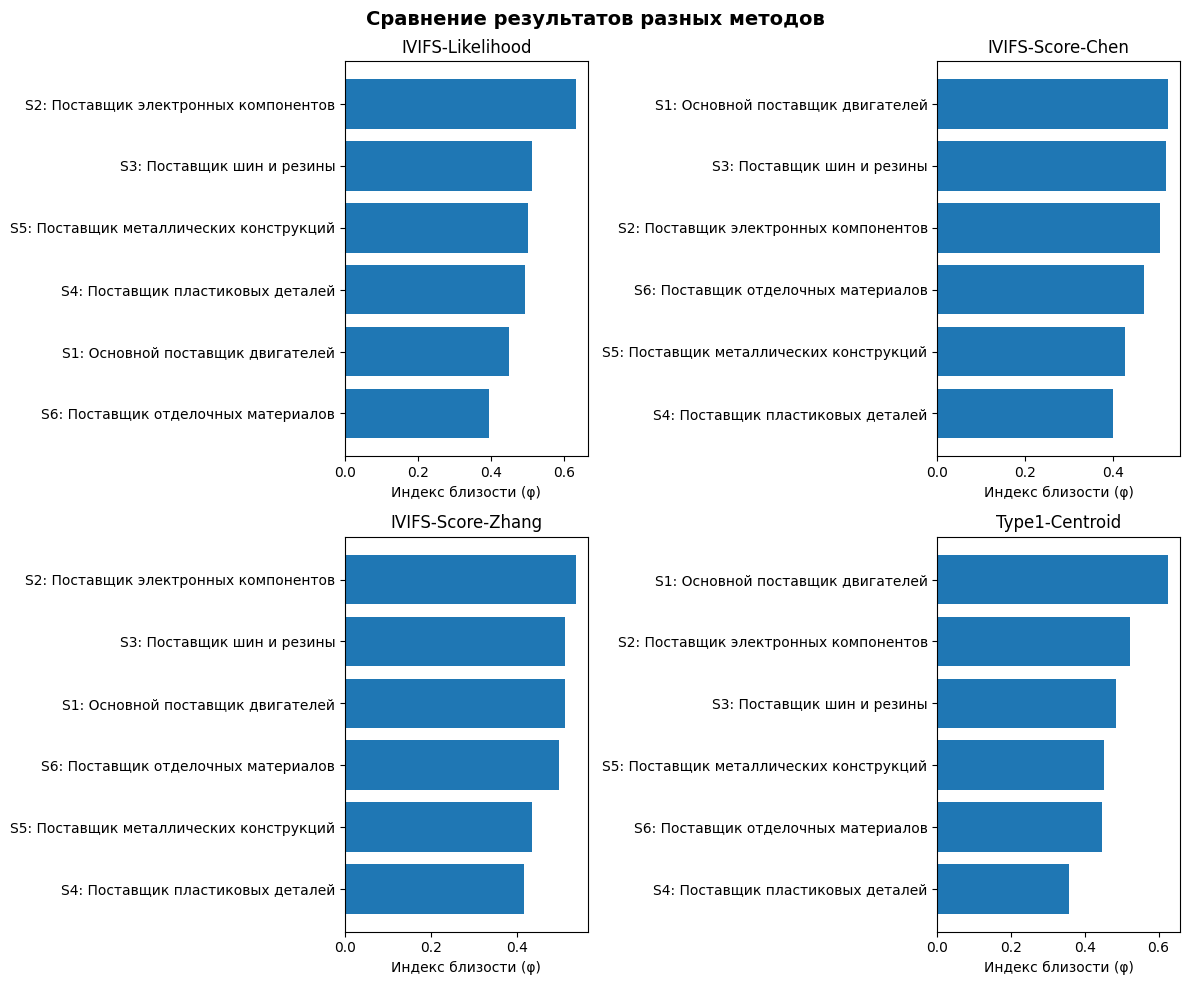

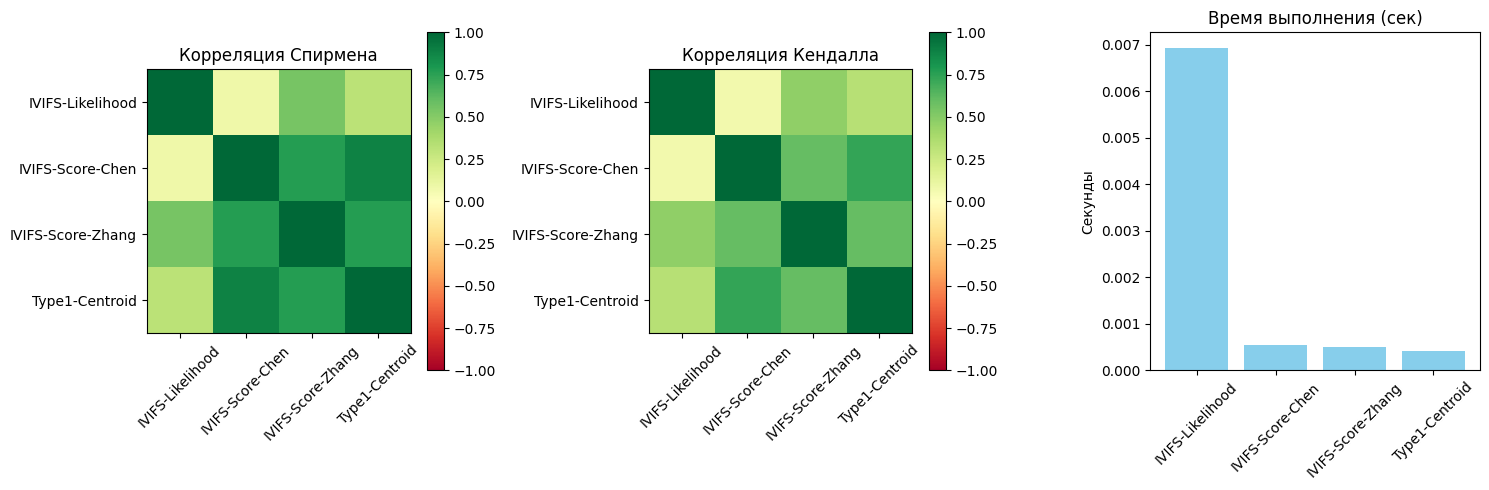

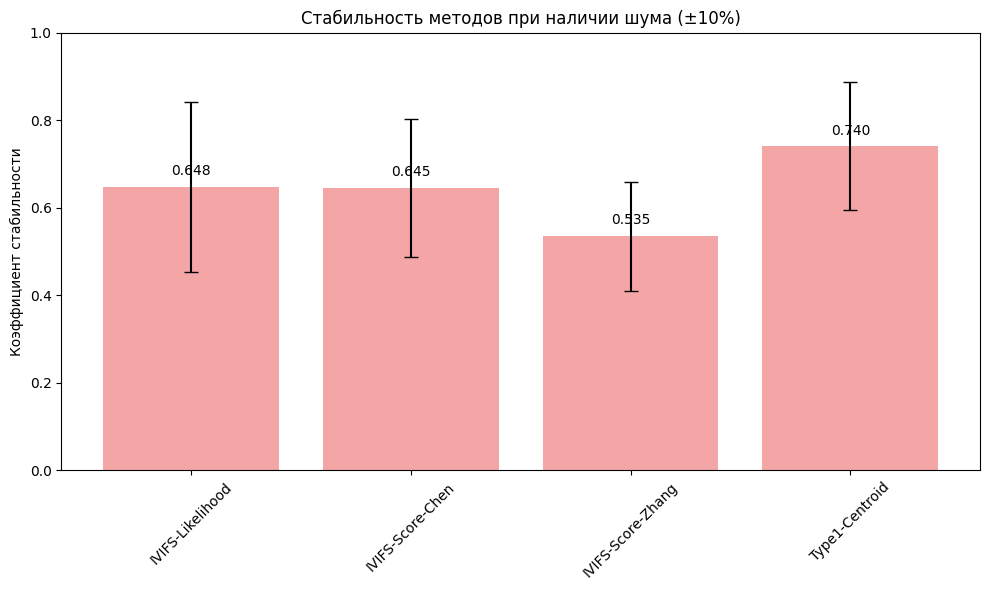

In [4]:
# 1. Создайте файл dataIn.json с вашими данными
# 2. Запустите конвейер
pipeline = TOPSISComparativePipeline('dataIn.json', verbose=True) # HendianiBagherpour2020.json
results = pipeline.run_comparative_analysis(analyze_sensitivity=True)

# 3. Анализируйте результаты
print("Корреляция Спирмена:", results['comparison_metrics']['spearman_correlation'])
print("Сходство топ-3:", results['comparison_metrics']['top_k_similarity']['top3'])
print("Стабильность методов:", results['sensitivity_results'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Последовательное тестирование

Загружено: 4 альтернатив, 3 критериев, 3 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0004 сек
Топ-3 альтернатив:
  1. Проект C (φ=0.6540)
  2. Проект D (φ=0.5715)
  3. Проект B (φ=0.4315)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0002 сек
Топ-3 альтернатив:
  1. Проект A (φ=1.0000)
  2. Проект B (φ=0.8047)
  3. Проект C (φ=0.4818)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0002 сек
Топ-3 альтернатив:
  1. Проект A (φ=1.0000)
  2. Проект B (φ=0.8143)
  3. Проект C (φ=0.4770)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выполнения: 0.0002 сек
Топ-3 альтернатив:
  1. Проект A (φ=1.0000)
  2. Проект B (φ=0.8032)
  3. Проект C (φ=0.4325)

📊 РАСЧЁТ МЕТРИК СРАВНЕНИЯ

📊 АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: medium)

Анализ метода: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения:

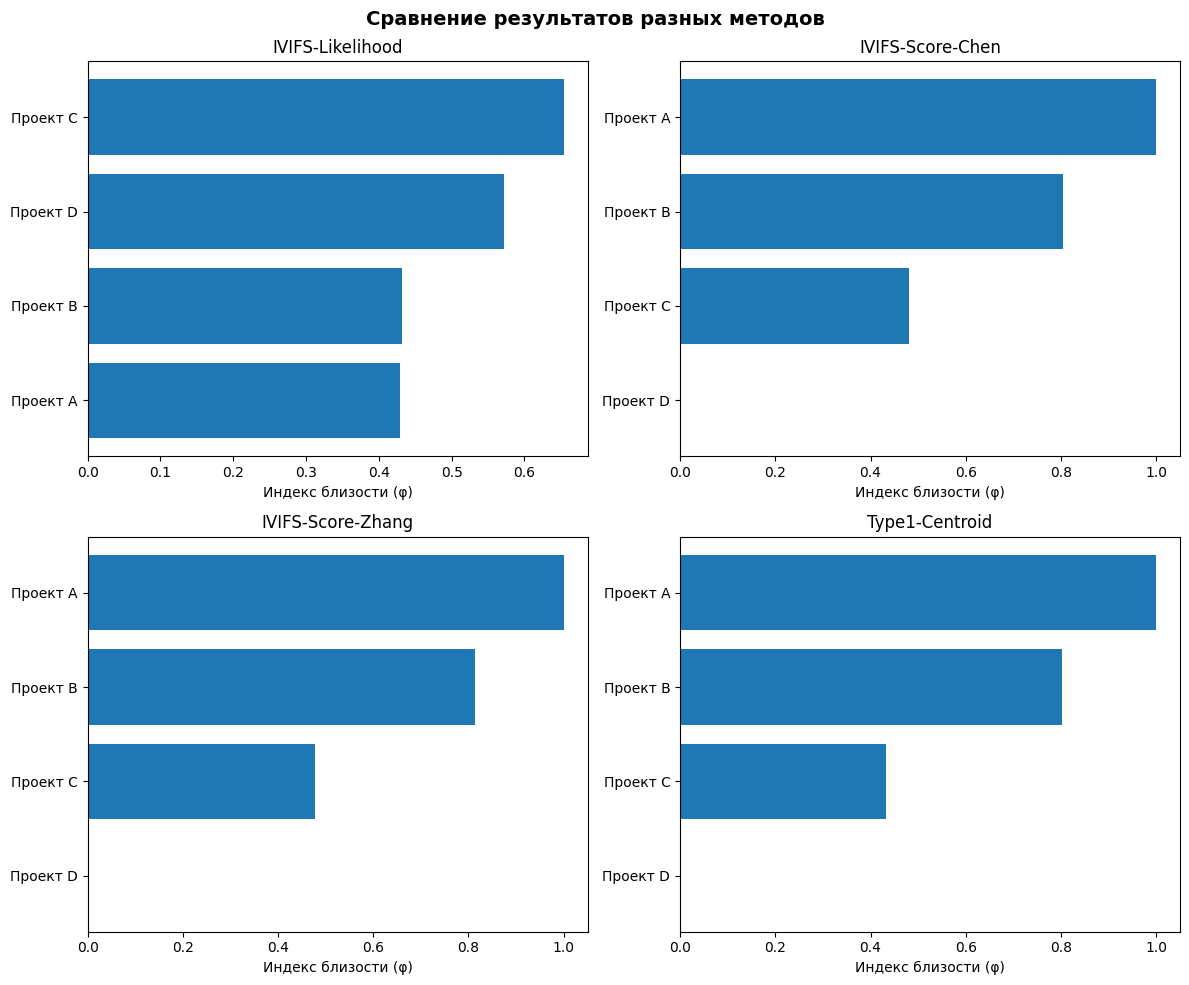

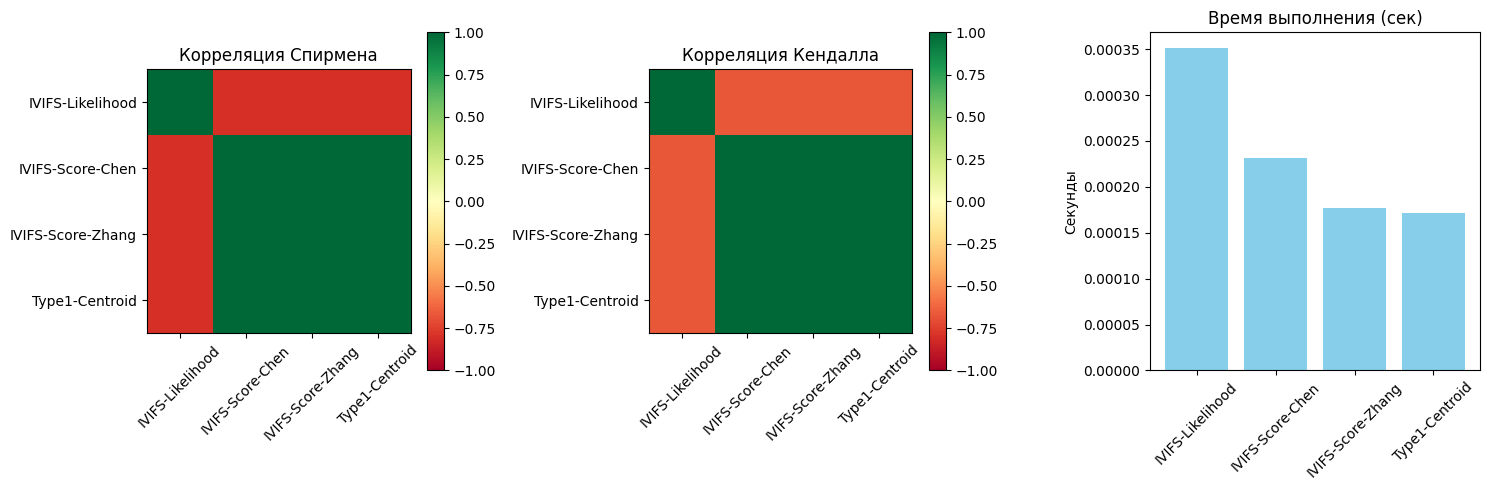

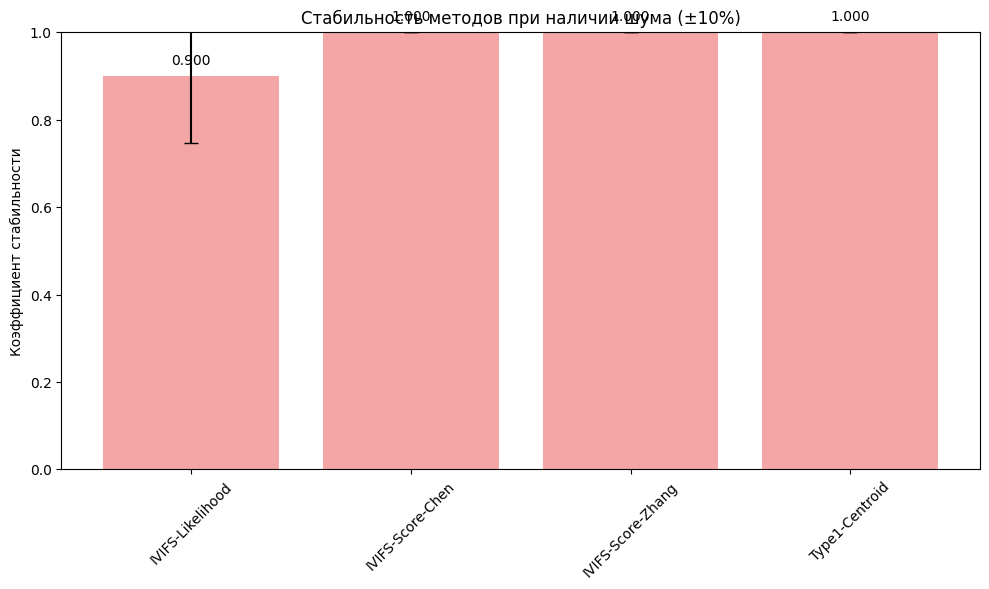

In [5]:
# Простой случай
pipeline = TOPSISComparativePipeline('1set.json') #case_study_1_consistent.json
results1 = pipeline.run_comparative_analysis()

Загружено: 3 альтернатив, 4 критериев, 3 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0010 сек
Топ-3 альтернатив:
  1. Технология Y (φ=0.5189)
  2. Технология X (φ=0.4769)
  3. Технология Z (φ=0.2424)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0007 сек
Топ-3 альтернатив:
  1. Технология Z (φ=0.8031)
  2. Технология Y (φ=0.6053)
  3. Технология X (φ=0.3730)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0003 сек
Топ-3 альтернатив:
  1. Технология Z (φ=0.8131)
  2. Технология Y (φ=0.5874)
  3. Технология X (φ=0.4033)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выполнения: 0.0008 сек
Топ-3 альтернатив:
  1. Технология Z (φ=0.7317)
  2. Технология X (φ=0.6214)
  3. Технология Y (φ=0.3957)

📊 РАСЧЁТ МЕТРИК СРАВНЕНИЯ

📊 АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: medium)

Анализ метода: IVIFS-Likelih

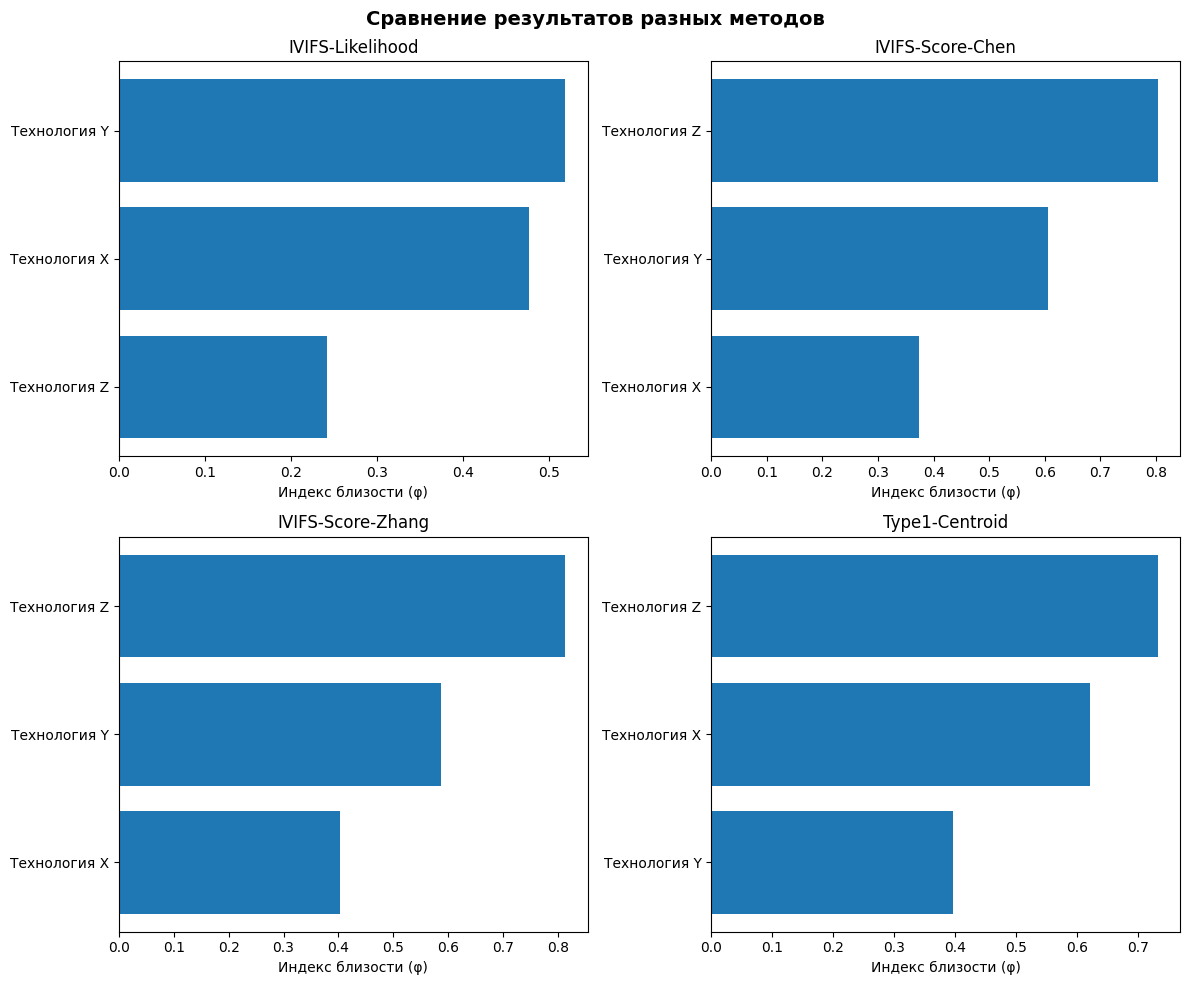

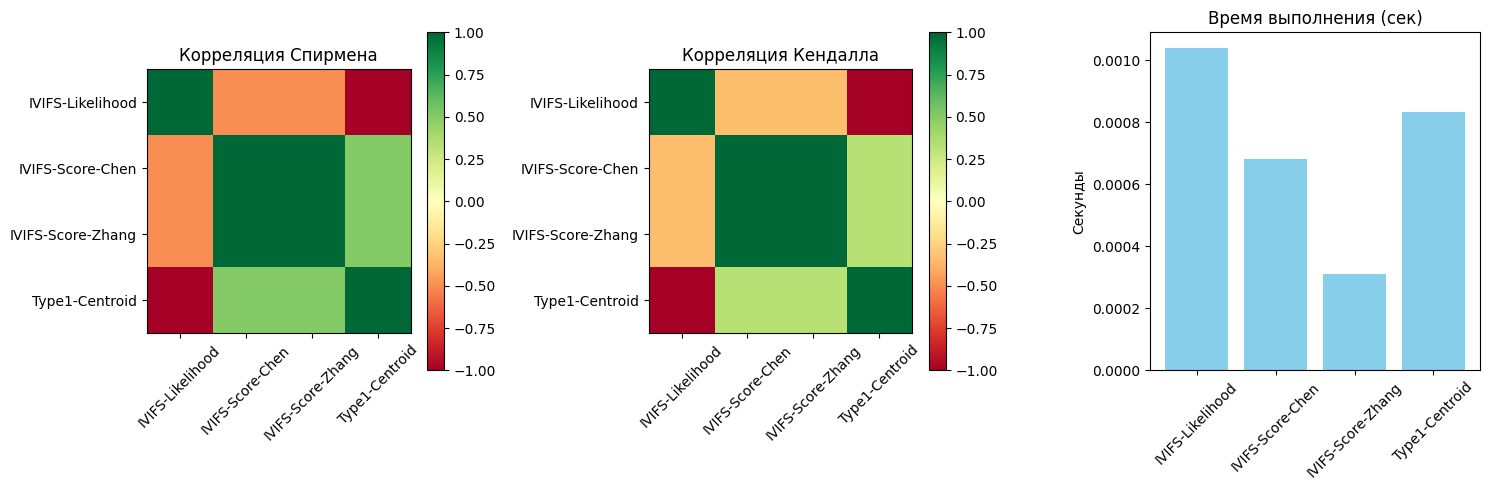

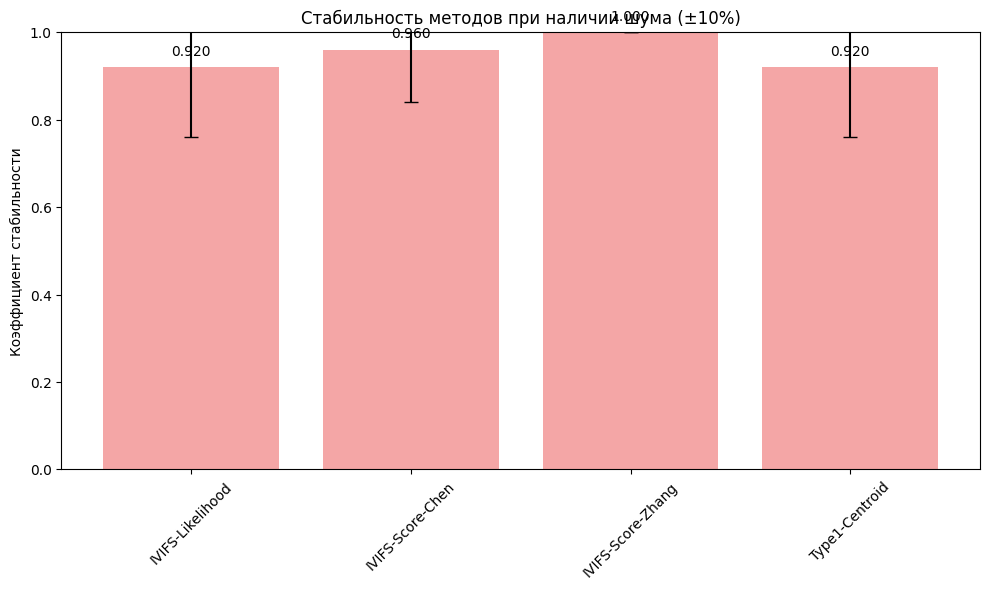

In [6]:
# Умеренная сложность
pipeline = TOPSISComparativePipeline('2set.json') #case_study_2_moderate.json
results2 = pipeline.run_comparative_analysis()

Загружено: 4 альтернатив, 5 критериев, 4 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0010 сек
Топ-3 альтернатив:
  1. Кандидат Delta (φ=0.6277)
  2. Кандидат Alpha (φ=0.6216)
  3. Кандидат Beta (φ=0.5715)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0004 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.8217)
  2. Кандидат Beta (φ=0.7350)
  3. Кандидат Delta (φ=0.3263)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0003 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.8860)
  2. Кандидат Beta (φ=0.7288)
  3. Кандидат Delta (φ=0.3028)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выполнения: 0.0002 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.7766)
  2. Кандидат Beta (φ=0.6529)
  3. Кандидат Delta (φ=0.3421)

📊 РАСЧЁТ МЕТРИК СРАВНЕНИЯ

📊 АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: medium)

Анализ м

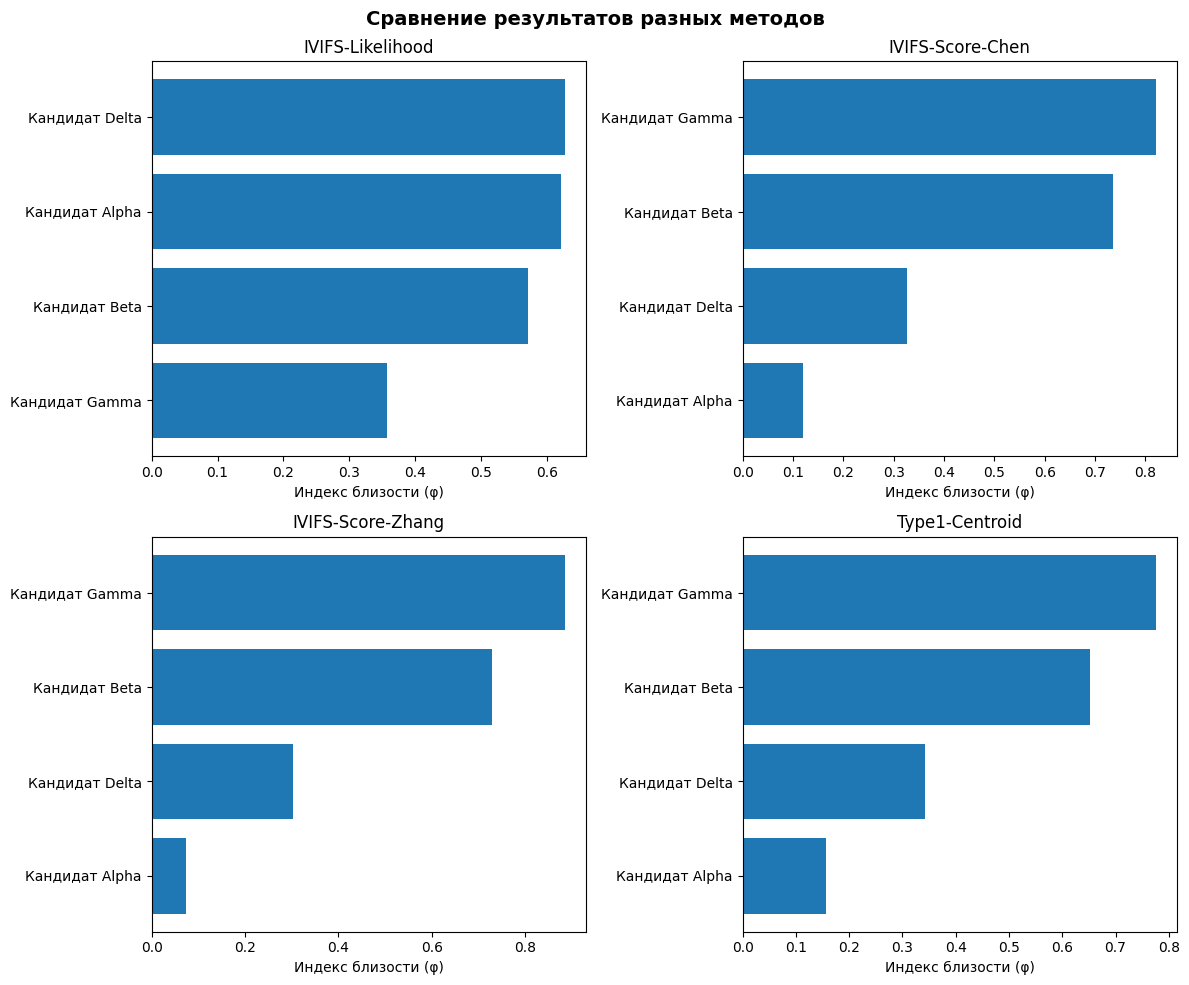

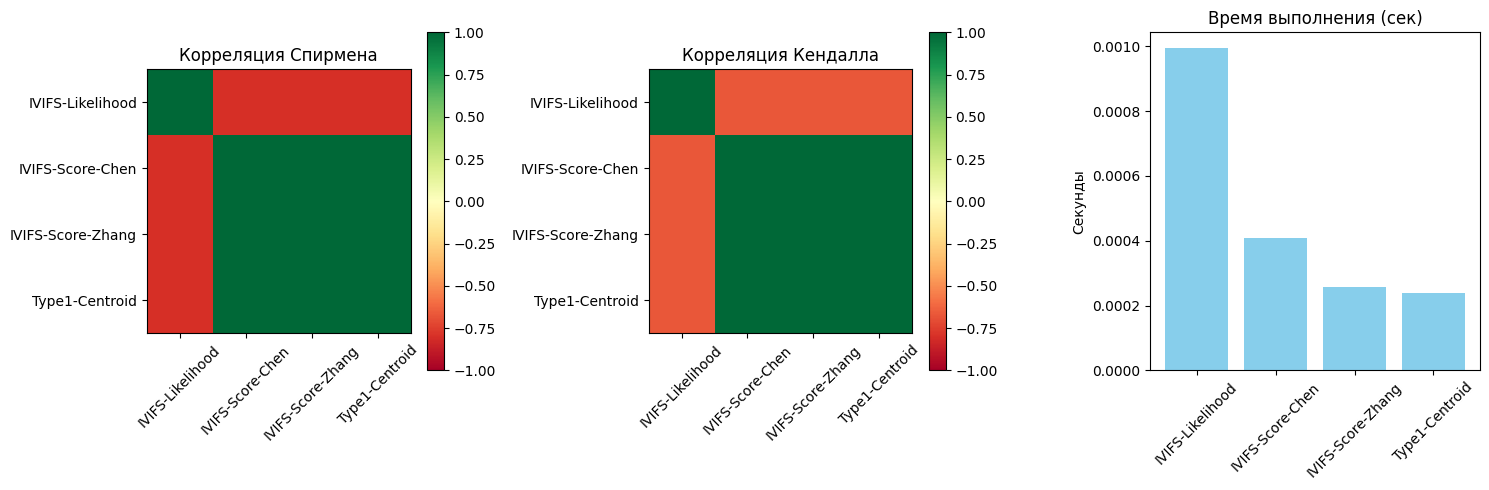

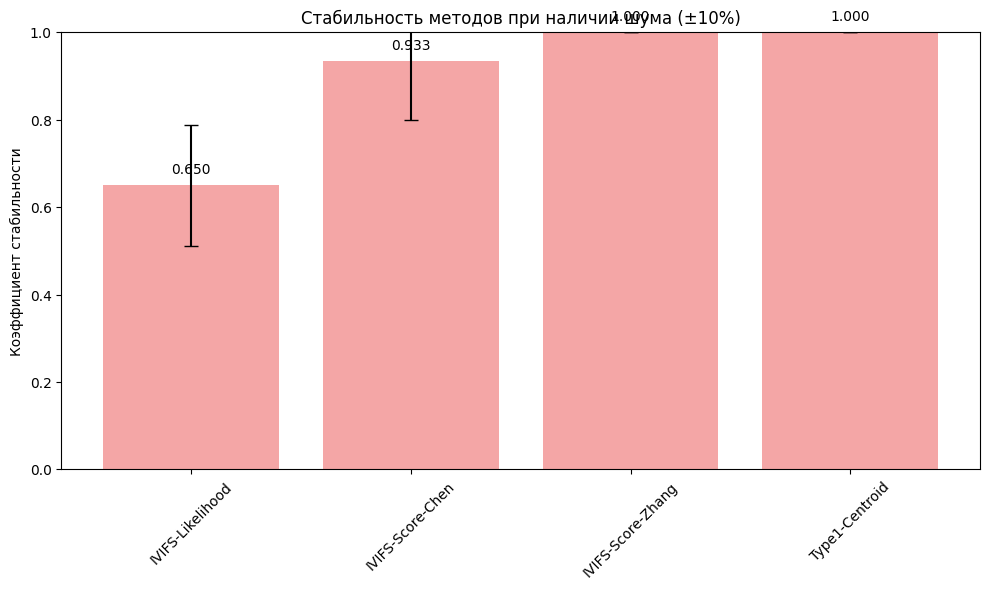

In [7]:
# Сложный случай
pipeline = TOPSISComparativePipeline('3set.json') #case_study_3_conflicting.json
results3 = pipeline.run_comparative_analysis()